## Carga del data set de Pathmnist


In [4]:
import medmnist
from medmnist import PathMNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torch

In [ ]:
# Deben descargar esto para iniciar el dataset
%pip install medmnist

## Convertir a tensor

Las imágenes de data set se transforman en un tensor con intensidades RGB por pixel
Además se pone el parámetro `download = True` para que en su entorno local no tengan que aguantar la descarga de 9 minutos cada vez que utilicen el dataset en otros notebooks
- `size=28` es para indicar la resolución en la que se descargarán las imágenes. En este caso: 28x28 pixéles

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

# Importante aca -> Medmnist no te da un dataset entero, por lo tanto, para que hagas el EDA debes ocupar estos 3 splits juntos
train_dataset = PathMNIST(split="train", transform=transform, download=True, size=28)
val_dataset   = PathMNIST(split="val", transform=transform, download=True, size=28)
test_dataset  = PathMNIST(split="test", transform=transform, download=True, size=28)

print(train_dataset)
print(val_dataset)
print(test_dataset)

100%|██████████| 206M/206M [09:09<00:00, 374kB/s] 


Dataset PathMNIST of size 28 (pathmnist)
    Number of datapoints: 89996
    Root location: C:\Users\panch\.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
    Number of samples: {'train': 89996, 'val': 10004, 'test': 7180}
    Description: The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CR

En esta celda podemos observar 
- el tipo de imágen: un tensor de torch
- El shape de la imágen -> torc.shize(3, 28, 28). El 3 se refiere a los canales, en este caso RGB ( azul rojo y verde) y `28, 28`  a la resolución en pixeles de la imágen
- Label en este caso devuelve un array con un número el cual indica la clase a la que pertenece la imágen.

Las 9 clases presentes son: 

    - [0] adipose -> Tejido adiposo
    - [1] background -> Fondo
    - [2] debris -> Detritos celulares
    - [3] lymphocytes -> linfocítos
    - [4] mucus -> Mucus
    - [5] smooth muscle -> Musculo liso
    - [6] normal colon mucosa -> Mucosa normal de colon
    - [7] cancer-associated stroma -> Estroma asociado a cáncer
    - [8] colorectal adenocarcinoma epithelium -> Epitelio de adenocarcinoma colorrectal

In [6]:
image, label = train_dataset[0]

print("Tipo de imagen:", type(image))
print("Shape de imagen:", image.shape)
print("Label:", label)

Tipo de imagen: <class 'torch.Tensor'>
Shape de imagen: torch.Size([3, 28, 28])
Label: [0]


## Visualizar una imágen

Arriba se vio que el tensor torch viene de  la forma `(3, 28 ,28)`
Eso en terminos de parámetros es `[Channeles (canales), Height (Altura), Width (Ancho)]`
Para "graficar esta imagen", tenemos que saber que matplotlib espera un formato `[HEIGHT, WIDTH, CHANNELS]`, por lo cual se debe permutar el tensor para poder gráficar


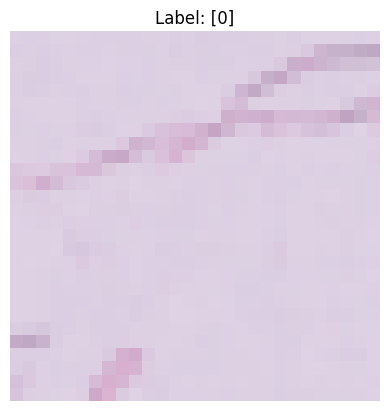

In [ ]:
image, label = train_dataset[0]

img = image.permute(1, 2, 0)
'''
Para que entiendan esto (1,2 0)
El valor en el indice 1 pasa al indice 0
El valor en el indice 2 pasa al indice 1
El valor en el indice 0 pasa al indice 2
Asi, tendremos  H x W x C
'''

plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [ ]:
image, label = train_dataset[1]


# Esto despues lo podemos pasar a una funcion y crear un /utils para poder mapear los nombres en plots o tablas segun el label en vez de mostrar el valor en corchetes
label_class_map = {
    0:'adipose',
    1:'background',
    2:'debris',
    3:'lymphocytes',
    4:'mucus',
    5:'smooth muscle',
    6:'normal colon mucosa',
    7:'cancer-associated stroma',
    8:'colorectal adenocarcinoma epithelium',
}

label_id = int(label[0])
label_name = label_class_map[label_id]

label_name


'mucus'

# Muestra
Esta es una forma en la que se puede mostrar un sample de los datos, que en este caso son imágenes

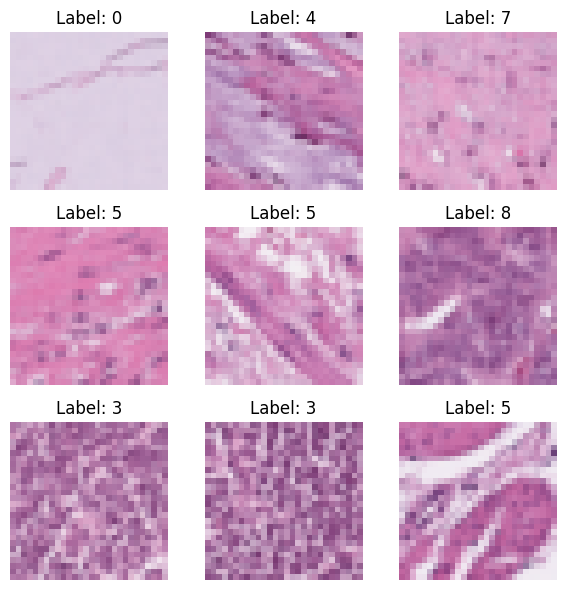

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(6, 6))


for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    img = image.permute(1, 2, 0)
    
    ax.imshow(img)
    ax.set_title(f"Label: {int(label[0])}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
info = medmnist.INFO["pathmnist"]

print("Nombre:", info["python_class"])
print("Tarea:", info["task"])
print("Canales:", info["n_channels"])
print("Número de clases:", len(info["label"]))
print("Clases:")
print(info["label"])

Nombre: PathMNIST
Tarea: multi-class
Canales: 3
Número de clases: 9
Clases:
{'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}


In [10]:
labels = train_dataset.labels.flatten()

unique, counts = np.unique(labels, return_counts=True)

for label, count in zip(unique, counts):
    print(f"Clase {label}: {count} imágenes")

Clase 0: 9366 imágenes
Clase 1: 9509 imágenes
Clase 2: 10360 imágenes
Clase 3: 10401 imágenes
Clase 4: 8006 imágenes
Clase 5: 12182 imágenes
Clase 6: 7886 imágenes
Clase 7: 9401 imágenes
Clase 8: 12885 imágenes


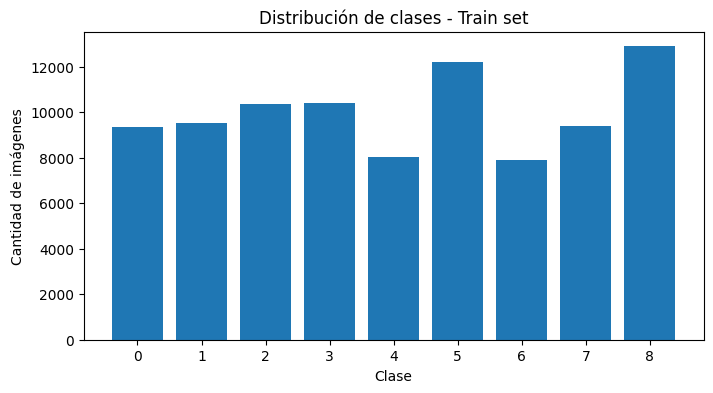

In [11]:
plt.figure(figsize=(8, 4))
plt.bar(unique, counts)
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de clases - Train set")
plt.xticks(unique)
plt.show()

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

Usando dispositivo: cpu


## Nota para seba

En teoria los EDA son del dataset en conjunto, pero como no viene junto tienes que juntar los splits.
Tambien es correcto hacer un conteo x ejemplo de clases y disribución x cada split